## Matryoshka truncation

In [12]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util, evaluation
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator, SimilarityFunction

In [ ]:
model_name=["tomaarsen/mpnet-base-nli-matryoshka", "tomaarsen/mpnet-base-nli"]
model_labels = ["Matryoshka model", "Original model"]



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 22777.09it/s]


In [14]:
stsb_dataset = load_dataset("mteb/stsbenchmark-sts", split="test")

In [15]:
sentences1 = stsb_dataset["sentence1"]
sentences2 = stsb_dataset["sentence2"]
scores = [score / 5.0 for score in stsb_dataset["score"]]

In [32]:
dimensions = [768, 512, 256, 128, 64, 32, 16, 8]
results = {name: [] for name in model_labels}

In [33]:
for model, label in zip(model_name, model_labels):
    for dim in dimensions:
        print(dim)
        truncated_model = SentenceTransformer(model, truncate_dim=dim)
        evaluator = EmbeddingSimilarityEvaluator(sentences1, sentences2, scores, main_similarity=SimilarityFunction.COSINE, name="sts-test")
        score = evaluator(truncated_model)
        results[label].append(score['sts-test_spearman_cosine'])

768


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16882.07it/s]


512


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16021.09it/s]


256


...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15427.65it/s]


16


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15781.18it/s]


8


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15054.23it/s]


In [34]:
results

{'Matryoshka model': [0.8680778027458498,
  0.8675781266909046,
  0.8666442271939763,
  0.862034739582352,
  0.853988448036032,
  0.8238981388521466,
  0.7714234002591221,
  0.6898751575532251],
 'Original model': [0.8614945497739034,
  0.8612366634774488,
  0.857546785879687,
  0.8496001267117715,
  0.8310404797155185,
  0.7974385083062788,
  0.7375210816917799,
  0.6440286545519179]}

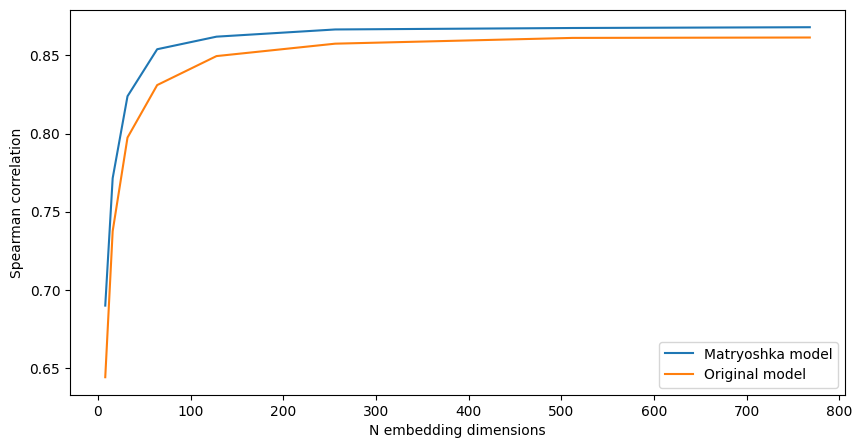

In [36]:
plt.figure(figsize=(10, 5))

for label in  model_labels:
    plt.plot(dimensions, results[label], label=label)

plt.xlabel("N embedding dimensions")
plt.ylabel("Spearman correlation")
plt.legend()